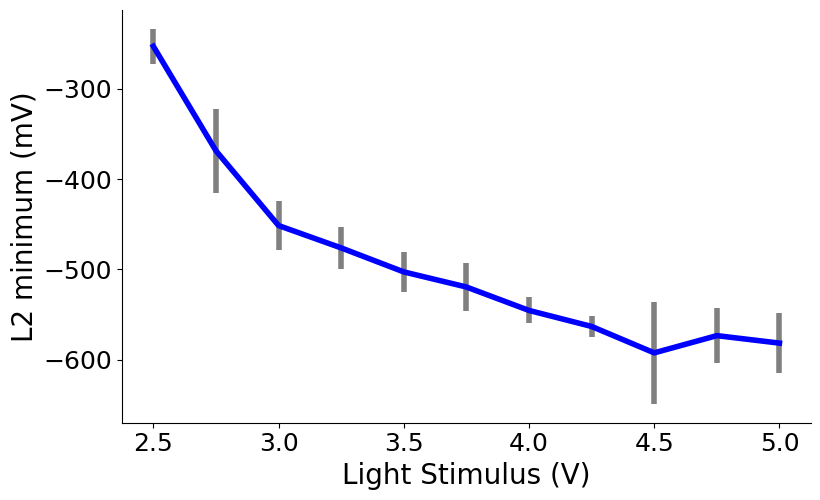

In [23]:
import matplotlib.pyplot as plt

# data import
stim_volt = [2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5]
L2_min_mV = [-253.24687, -368.78751, -451.43438, -476.14374, -502.68126, 
     -519.35623, -545.26874, -562.96249, -592.16876, -573.12187, -581.38438]
L2_error_mV = [19.35126894, 46.34688006, 26.61447871, 23.41388159, 21.78556892,
               26.03799283, 14.33071544, 11.88027929, 56.47972324, 30.18941102, 33.30457371]

# Create plot
plt.figure(figsize=(8,5))
plt.errorbar(stim_volt, L2_min_mV, yerr=L2_error_mV, linestyle='-', ecolor='gray', color='blue', linewidth=4)
ax = plt.gca()
# Labels and title
plt.xlabel('Light Stimulus (V)', fontsize=20)
plt.ylabel('L2 minimum (mV)', fontsize=20)

# Optional: plot clean up
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
ax.tick_params(axis='x', labelsize=18)  
ax.tick_params(axis='y', labelsize=18)

# Show the plot
plt.show()

Fitted parameters:
A = 13262.521
tau = 0.675
C = 12674.920
Equation: y = -13262.521 * (1 - exp(-x / 0.675)) + 12674.920


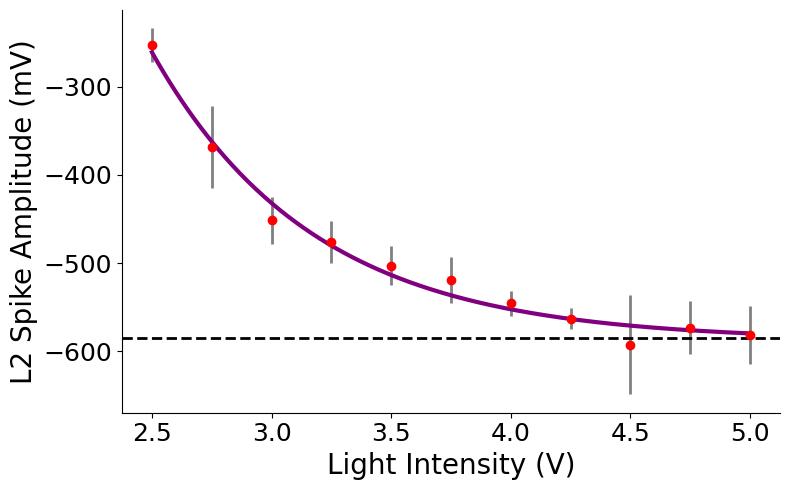

In [155]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
stim_volt = np.array([2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5])
L2_min_mV = np.array([-253.24687, -368.78751, -451.43438, -476.14374, -502.68126, 
                      -519.35623, -545.26874, -562.96249, -592.16876, -573.12187, -581.38438])
L2_error_mV = np.array([19.35126894, 46.34688006, 26.61447871, 23.41388159, 21.78556892,
                        26.03799283, 14.33071544, 11.88027929, 56.47972324, 30.18941102, 33.30457371])

# Define the negative RC function with +C
def neg_rc_curve(x, A, tau, C):
    return -A * (1 - np.exp(-x / tau)) + C

# Fit the curve to data
popt1, pcov2 = curve_fit(neg_rc_curve, stim_volt, L2_min_mV, p0=[400, 1, -600])

A1, tau1, C1 = popt1
print(f"Fitted parameters:")
print(f"A = {A1:.3f}")
print(f"tau = {tau1:.3f}")
print(f"C = {C1:.3f}")
print(f"Equation: y = -{A1:.3f} * (1 - exp(-x / {tau1:.3f})) + {C1:.3f}")

# Generate smooth fit line
x_fit = np.linspace(min(stim_volt), max(stim_volt), 300)
y_fit = neg_rc_curve(x_fit, *popt1)

# Plot data + fit
plt.figure(figsize=(8,5))
plt.errorbar(stim_volt, L2_min_mV, yerr=L2_error_mV, fmt='o', color='red',
             ecolor='gray', elinewidth=2, label='Data')
plt.plot(x_fit, y_fit, color='purple', linewidth=3, label='Negative RC Fit')

#min line
plt.axhline(y=-585, color='black', linestyle='--', linewidth=2, label='y = 400')
# Labels and formatting
plt.xlabel('Light Intensity (V)', fontsize=20)
plt.ylabel('L2 Spike Amplitude (mV)', fontsize=20)
ax = plt.gca()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=18)  
ax.tick_params(axis='y', labelsize=18)
plt.tight_layout()
plt.show()


Fitted parameters:
A = 43158.981
tau = 0.514
C = -42629.357
Equation: y = -43158.981 * (1 - exp(-x / 0.514)) + -42629.357


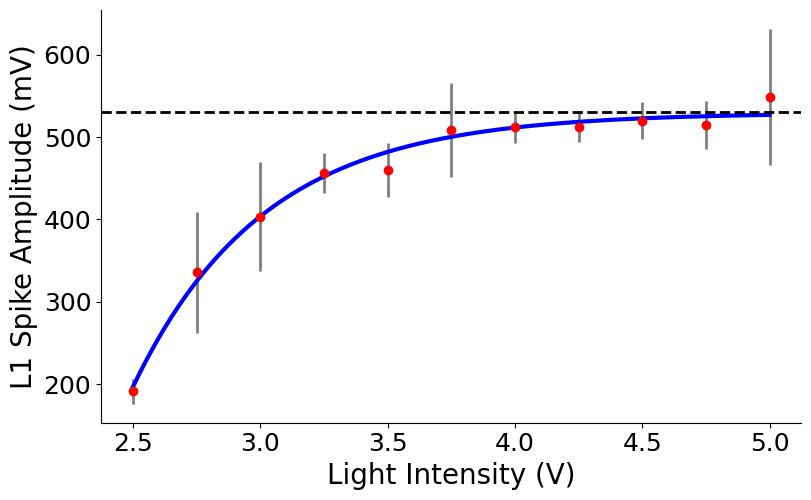

In [154]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



# data import
stim_volt = [2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5]
L1_min_mV = [191.3, 335.8333333, 403.59688, 456.76874, 460.50625, 
            508.69374, 511.85, 512.90939, 520.20314, 514.59688, 548.94688]
L1_error_mV = [15.30337653, 73.52888055, 66.21426107, 24.02803132, 
                32.70082436, 56.54760534, 19.04141066, 18.53506825,
                 22.89117169, 29.42383721, 82.65730593]

# Define the RC-like function
def rc_curve(x, A, tau, C):
    return A * (1 - np.exp(-x / tau)) + C

# Fit the curve to your data
popt2, pcov2 = curve_fit(rc_curve, stim_volt, L1_min_mV, p0=[400, 1, 100])

# Generate smooth curve for plotting
x_fit = np.linspace(min(stim_volt), max(stim_volt), 200)
y_fit = rc_curve(x_fit, *popt2)

# Plot data with error bars
plt.figure(figsize=(8,5))
plt.errorbar(stim_volt, L1_min_mV, yerr=L1_error_mV, fmt='o', color='red',
             ecolor='gray', elinewidth=2, label='Data')

# Plot the RC-like fit
plt.plot(x_fit, y_fit, color='blue', linewidth=3, label='RC-like trendline')
# Labels and title
plt.xlabel('Light Intensity (V)', fontsize=20)
plt.ylabel('L1 Spike Amplitude (mV)', fontsize=20)
#max line
plt.axhline(y=530, color='black', linestyle='--', linewidth=2, label='y = 400')
# Optional: plot clean up
ax = plt.gca()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
ax.tick_params(axis='x', labelsize=18)  
ax.tick_params(axis='y', labelsize=18)

#print curve details
A2, tau2, C2 = popt2
print(f"Fitted parameters:")
print(f"A = {A2:.3f}")
print(f"tau = {tau2:.3f}")
print(f"C = {C2:.3f}")
print(f"Equation: y = -{A2:.3f} * (1 - exp(-x / {tau2:.3f})) + {C2:.3f}")



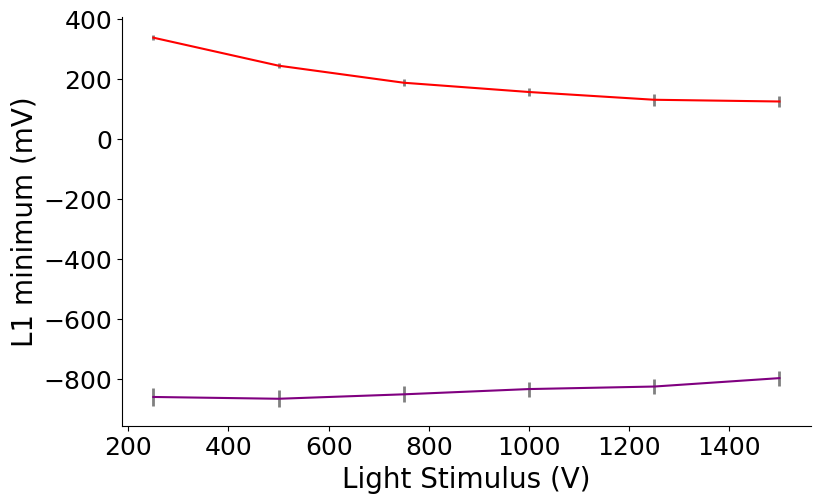

In [81]:
# data import
stim_temp = [250, 500, 750, 1000, 1250, 1500]
L1_max_mV_temp = [336.55, 243.232, 186.38, 155.486, 129.644, 123.88]
L1_error_mV_temp = [8.308, 8.587, 12.472, 14.301, 19.536, 18.755]
L2_min_mV_temp = [-860.606,-866.572, -851.782, -834.248, -825.844, -797.814]
L2_error_mV_temp = [28.815, 27.865, 26.155, 25.185, 25.185, 25.2125]

# Plot data with error bars
plt.figure(figsize=(8,5))
plt.errorbar(stim_temp, L1_max_mV_temp, yerr=L1_error_mV_temp, fmt='-', color='red',
             ecolor='gray', elinewidth=2, label='Data')
plt.errorbar(stim_temp, L2_min_mV_temp, yerr=L2_error_mV_temp, fmt='-', color='purple',
             ecolor='gray', elinewidth=2, label='Data')

# Labels and title
plt.xlabel('Light Stimulus (V)', fontsize=20)
plt.ylabel('L1 minimum (mV)', fontsize=20)
# Optional: plot clean up
ax = plt.gca()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
ax.tick_params(axis='x', labelsize=18)  
ax.tick_params(axis='y', labelsize=18)


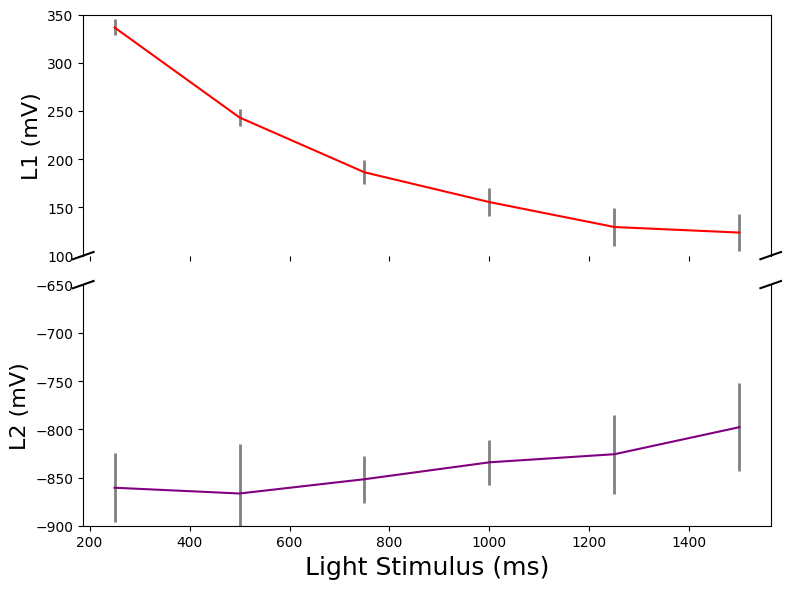

In [ ]:
import matplotlib.pyplot as plt

# Data
stim_temp = [250, 500, 750, 1000, 1250, 1500]
L1_max_mV_temp = [336.55, 243.232, 186.38, 155.486, 129.644, 123.88]
L1_error_mV_temp = [8.308, 8.587, 12.472, 14.301, 19.536, 18.755]
L2_min_mV_temp = [-860.606, -866.572, -851.782, -834.248, -825.844, -797.814]
L2_error_mV_temp = [35.782, 50.940, 24.207, 23.192, 40.935, 45.381]

# Create subplots with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8,6), height_ratios=[1,1])

# --- Upper plot (for L1 positive values) ---
ax1.errorbar(stim_temp, L1_max_mV_temp, yerr=L1_error_mV_temp, fmt='-', color='red',
             ecolor='gray', elinewidth=2, label='Data')
ax1.set_ylim(100, 350)





# --- Lower plot (for L2 negative values) ---
ax2.errorbar(stim_temp, L2_min_mV_temp, yerr=L2_error_mV_temp, fmt='-', color='purple',
             ecolor='gray', elinewidth=2, label='Data')
ax2.set_ylim(-900, -650)

# Remove top spines and bottom spines for clarity
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labeltop=False)  # hide top labels
ax2.xaxis.tick_bottom()

# Diagonal slashes to indicate a break in the y-axis
d = .015  # size of break marks
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Labels
ax2.set_xlabel('Light Stimulus (ms)', fontsize=18, )
ax1.set_ylabel('L1 (mV)', fontsize=16, )
ax2.set_ylabel('L2 (mV)', fontsize=16, )



plt.tight_layout()
plt.show()


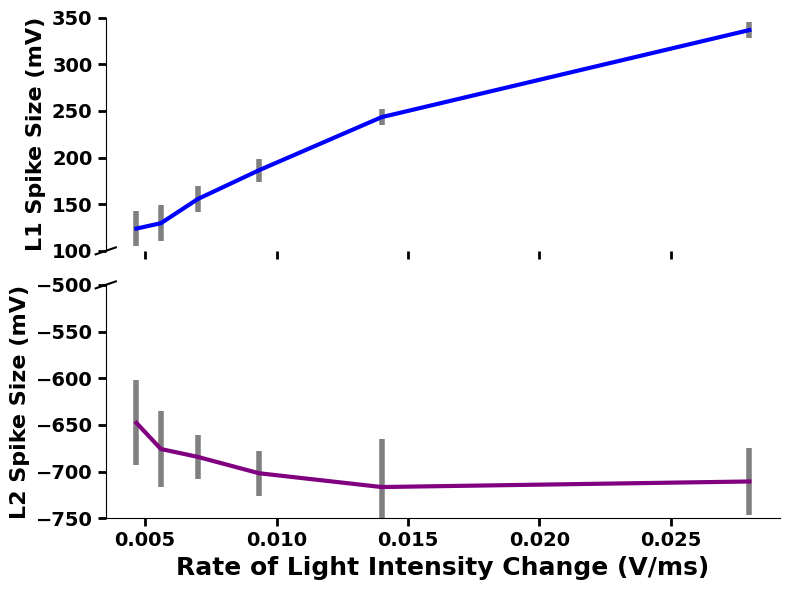

In [157]:
import matplotlib.pyplot as plt

# Data
stim_temp = [7/250, 7/500, 7/750, 7/1000, 7/1250, 7/1500]

L1_max_mV_temp = [336.55, 243.232, 186.38, 155.486, 129.644, 123.88]
L1_error_mV_temp = [8.308, 8.587, 12.472, 14.301, 19.536, 18.755]
L2_min_mV_temp = [-710.606, -716.572, -701.782, -684.248, -675.844, -647.814]
L2_error_mV_temp = [35.782, 50.940, 24.207, 23.192, 40.935, 45.381]

# Create subplots with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8,6), height_ratios=[1,1])

# --- Upper plot (L1 positive values) ---
ax1.errorbar(stim_temp, L1_max_mV_temp, yerr=L1_error_mV_temp,
             fmt='-', color='blue', ecolor='gray', elinewidth=4, linewidth=3, label='L1')
ax1.set_ylim(100, 350)

# --- Lower plot (L2 negative values) ---
ax2.errorbar(stim_temp, L2_min_mV_temp, yerr=L2_error_mV_temp,
             fmt='-', color='purple', ecolor='gray', elinewidth=4, linewidth=3, label='L2')
ax2.set_ylim(-750, -500)

# Remove unwanted spines (top/right on both)
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Remove connecting spines between subplots for clarity
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Tick formatting — bold labels + thick ticks
for ax in [ax1, ax2]:
    ax.tick_params(axis='x', labelsize=14, width=2, length=6)
    ax.tick_params(axis='y', labelsize=14, width=2, length=6)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontweight('bold')

# Diagonal slashes — only on the LEFT side now
d = .015  # size of break marks
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # top-left
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left

# Labels
ax2.set_xlabel('Rate of Light Intensity Change (V/ms)', fontsize=18, fontweight='bold')
ax1.set_ylabel('L1 Spike Size (mV)', fontsize=16, fontweight='bold')
ax2.set_ylabel('L2 Spike Size (mV)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


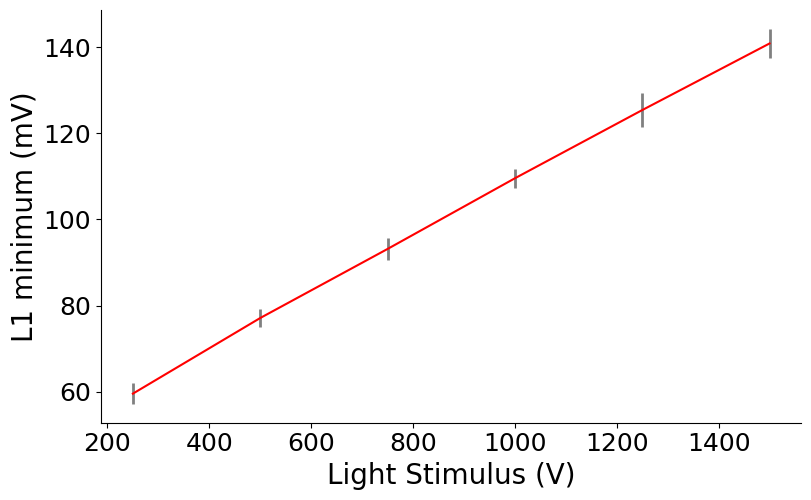

In [84]:
# data import
stim_temp = [250, 500, 750, 1000, 1250, 1500]
L1_time_mV_temp = [59.535, 77.095, 93.13, 109.54, 125.3775, 140.845]
L1_time_error_mV_temp = [2.393, 2.072, 2.578, 2.175, 3.912, 3.416]



# Plot data with error bars
plt.figure(figsize=(8,5))
plt.errorbar(stim_temp, L1_time_mV_temp, yerr=L1_time_error_mV_temp, fmt='-', color='red',
             ecolor='gray', elinewidth=2, label='Data')



# Labels and title
plt.xlabel('Light Stimulus (V)', fontsize=20)
plt.ylabel('L1 minimum (mV)', fontsize=20)
# Optional: plot clean up
ax = plt.gca()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
ax.tick_params(axis='x', labelsize=18)  
ax.tick_params(axis='y', labelsize=18)

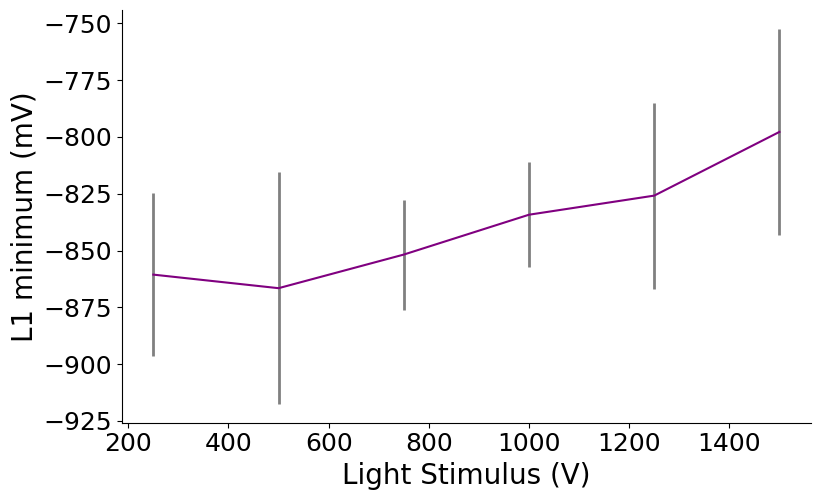

In [91]:
# data import
stim_temp = [250, 500, 750, 1000, 1250, 1500]
L2_min_mV_temp = [-860.606,-866.572, -851.782, -834.248, -825.844, -797.814]
L2_error_mV_temp = [35.782, 50.940, 24.207, 23.192, 40.935, 45.381]


# Plot data with error bars
plt.figure(figsize=(8,5))
plt.errorbar(stim_temp, L2_min_mV_temp, yerr=L2_error_mV_temp, fmt='-', color='purple',
             ecolor='gray', elinewidth=2, label='Data')

# Labels and title
plt.xlabel('Light Stimulus (V)', fontsize=20)
plt.ylabel('L1 minimum (mV)', fontsize=20)
# Optional: plot clean up
ax = plt.gca()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
ax.tick_params(axis='x', labelsize=18)  
ax.tick_params(axis='y', labelsize=18)


/var/folders/9_/4mdlvw6532z4__2_2my48mj00000gn/T/ipykernel_13919/3016295067.py:11: RuntimeWarning: invalid value encountered in log
  return a - b * np.log(x + c)


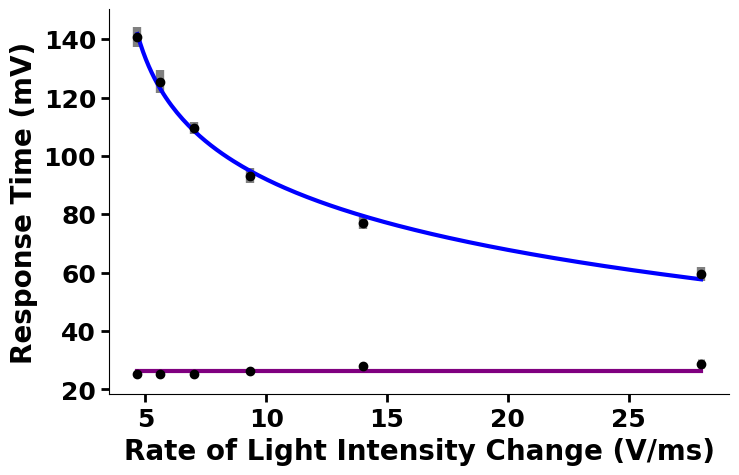

28.0
Fitted equation: y = 137.804 - 25.147 * ln(x + -3.811514)


In [159]:
import matplotlib.pyplot as plt

# Data import
# --- Data import ---
stim_temp_scaled = np.array([7/.250, 7/.500, 7/.750, 7/1.000, 7/1.250, 7/1.500])
L1_time_mV_temp = np.array([59.535, 77.095, 93.13, 109.54, 125.3775, 140.845])
L1_time_error_mV_temp = np.array([2.393, 2.072, 2.578, 2.175, 3.912, 3.416])

# --- Define a negative inverted log function ---
def neg_inverted_log(x, a, b, c):
    return a - b * np.log(x + c)

# --- Fit the curve to the scaled x ---
popt, _ = curve_fit(neg_inverted_log, stim_temp_scaled, L1_time_mV_temp, p0=[150, 50, 0.001])

x_fit = np.linspace(min(stim_temp_scaled), max(stim_temp_scaled), 200)
y_fit = neg_inverted_log(x_fit, *popt)


# L2 data
L2_time_mV_temp = [28.815, 27.865, 26.155, 25.185, 25.185, 25.2125]
L2_time_error_mV_temp = [1.561, 0.425, 0.850, 0.861, 0.861, 0.922]

#horizontal line array

horizontal_line = [26.155,26.155,26.155,26.155,26.155,26.155]
# --- Create single combined plot ---
plt.figure(figsize=(8,5))
# --- Plot L1 with error bars ---
plt.errorbar(stim_temp_scaled, L1_time_mV_temp, yerr=L1_time_error_mV_temp,
             fmt='o', color='black', ecolor='gray', elinewidth=6, label='L1 Time (data)')



# Plot L2
plt.errorbar(stim_temp_scaled, L2_time_mV_temp, yerr=L2_time_error_mV_temp,
     
             fmt='o', color='black', ecolor='gray', elinewidth=5, linewidth=3,label='L2 Time (mV)')
# --- Plot fitted inverted log curve ---
plt.plot(x_fit, y_fit, color='blue', linewidth=3, label='Negative Inverted Log Fit')
# --- Plot horizontal line ---
plt.plot(stim_temp_scaled, horizontal_line, color='purple', linewidth=3, label='Negative Inverted Log Fit')


# Labels and title
plt.xlabel('Rate of Light Intensity Change (V/ms)', fontsize=20, fontweight='bold')
plt.ylabel('Response Time (mV)', fontsize=20, fontweight='bold')

# Clean up and style
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=18, width=2, length=6)
ax.tick_params(axis='y', labelsize=18, width=2, length=6)

# Bold tick labels
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontweight('bold')



# Show combined plot
plt.show()

n=7000/250
print (n)
# --- Print fitted equation ---
a, b, c = popt
print(f"Fitted equation: y = {a:.3f} - {b:.3f} * ln(x + {c:.6f})")

/var/folders/9_/4mdlvw6532z4__2_2my48mj00000gn/T/ipykernel_13919/1538768210.py:12: RuntimeWarning: invalid value encountered in log
  return a - b * np.log(x + c)


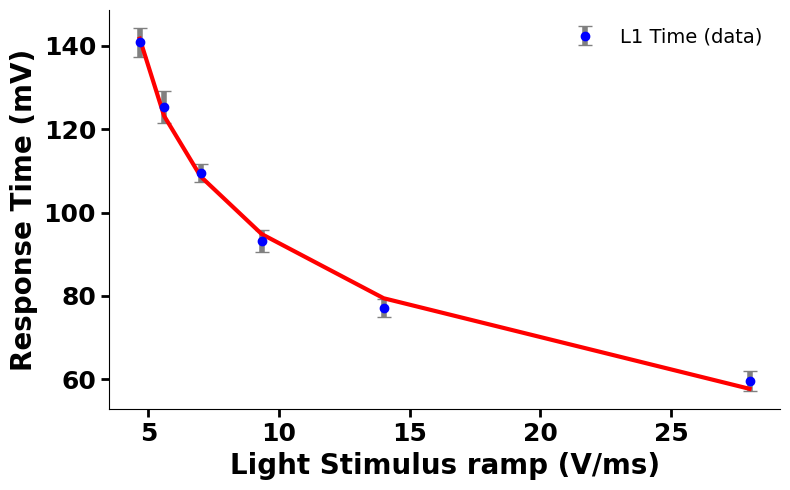

Fitted parameters [a, b, c]: [137.80403449  25.14711626  -3.81151445]


In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Data import ---
stim_temp_scaled = np.array([7/.250, 7/.500, 7/.750, 7/1.000, 7/1.250, 7/1.500])
L1_time_mV_temp = np.array([59.535, 77.095, 93.13, 109.54, 125.3775, 140.845])
L1_time_error_mV_temp = np.array([2.393, 2.072, 2.578, 2.175, 3.912, 3.416])

# --- Define a negative inverted log function ---
def neg_inverted_log(x, a, b, c):
    return a - b * np.log(x + c)

# --- Fit the curve to the scaled x ---
popt, _ = curve_fit(neg_inverted_log, stim_temp_scaled, L1_time_mV_temp, p0=[150, 50, 0.001])

x_fit = np.linspace(min(stim_temp_scaled), max(stim_temp_scaled), 200)
y_fit = neg_inverted_log(x_fit, *popt)

# --- Plot data with error bars ---
plt.figure(figsize=(8,5))
plt.errorbar(stim_temp_scaled, L1_time_mV_temp, yerr=L1_time_error_mV_temp,
             fmt='o', color='blue', ecolor='gray', elinewidth=4, capsize=5, label='L1 Time (data)')

# --- Plot fitted inverted log curve ---
plt.plot(stim_temp_scaled, neg_inverted_log(stim_temp_scaled, *popt), color='red', linewidth=3)

# --- Labels and formatting ---
plt.xlabel('Light Stimulus ramp (V/ms)', fontsize=20, fontweight='bold')
plt.ylabel('Response Time (mV)', fontsize=20, fontweight='bold')
plt.legend(fontsize=14, frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=18, width=2, length=6)
ax.tick_params(axis='y', labelsize=18, width=2, length=6)

for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

print("Fitted parameters [a, b, c]:", popt)


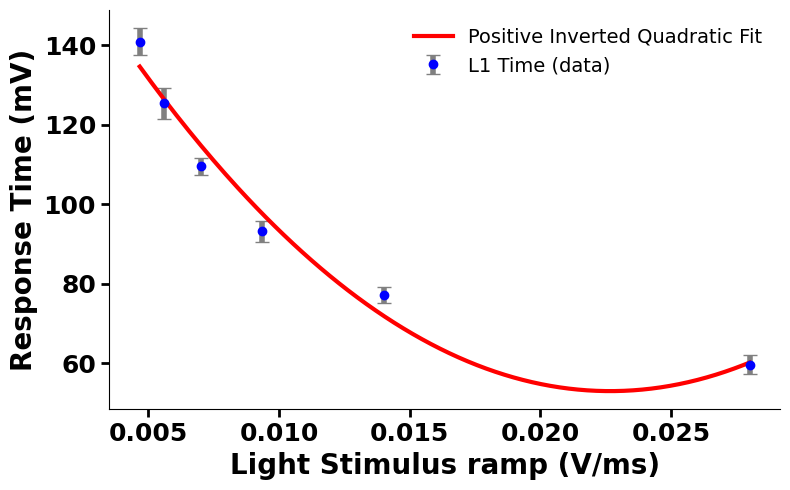

Fitted parameters [a, b, c]: [5.29587359e+01 2.52008569e+05 2.26656062e-02]


In [124]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Data import ---
stim_temp = np.array([7/250, 7/500, 7/750, 7/1000, 7/1250, 7/1500])
L1_time_mV_temp = np.array([59.535, 77.095, 93.13, 109.54, 125.3775, 140.845])
L1_time_error_mV_temp = np.array([2.393, 2.072, 2.578, 2.175, 3.912, 3.416])

# --- Define positive inverted quadratic (concave up) ---
def pos_inverted_quadratic(x, a, b, c):
    return a + b * (x - c)**2

# --- Fit curve to data ---
# initial guess: a≈min(y), b≈some positive number, c≈mean(x)
popt, _ = curve_fit(
    pos_inverted_quadratic, 
    stim_temp, L1_time_mV_temp, 
    p0=[min(L1_time_mV_temp), 10000, np.mean(stim_temp)]
)

# --- Generate smooth curve for plotting ---
x_fit = np.linspace(min(stim_temp), max(stim_temp), 200)
y_fit = pos_inverted_quadratic(x_fit, *popt)

# --- Plot data and fit ---
plt.figure(figsize=(8,5))
plt.errorbar(stim_temp, L1_time_mV_temp, yerr=L1_time_error_mV_temp,
             fmt='o', color='blue', ecolor='gray', elinewidth=4, capsize=5, label='L1 Time (data)')
plt.plot(x_fit, y_fit, color='red', linewidth=3, label='Positive Inverted Quadratic Fit')

# --- Labels and formatting ---
plt.xlabel('Light Stimulus ramp (V/ms)', fontsize=20, fontweight='bold')
plt.ylabel('Response Time (mV)', fontsize=20, fontweight='bold')
plt.legend(fontsize=14, frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=18, width=2, length=6)
ax.tick_params(axis='y', labelsize=18, width=2, length=6)
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

print("Fitted parameters [a, b, c]:", popt)
